In [1]:
import glob

images_path = glob.glob("../data/PNG/crop_and_pad/*")

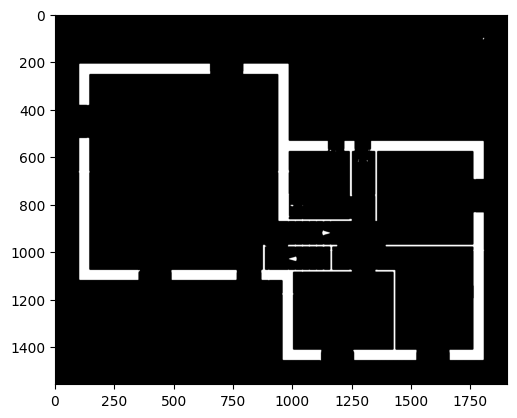

In [2]:
import cv2
import time
import random
from matplotlib import pyplot as plt

start_time = time.perf_counter()
random_idx = random.randint(0, len(images_path) - 1)
img = cv2.imread(images_path[random_idx], cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img, cmap="gray")
plt.show()

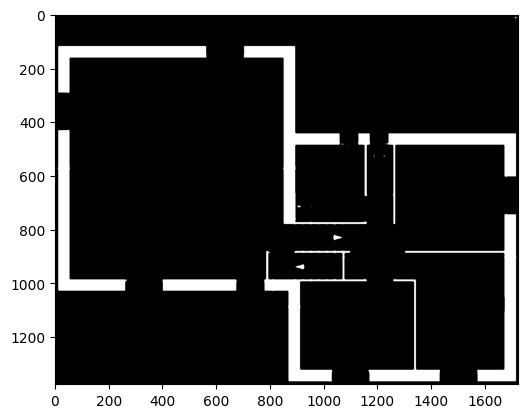

In [3]:
import numpy as np

def crop_to_content(binary, margin=10):
    """Crop binary image to bounding box of white pixels, with inward margin."""
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) == 0:
        return binary
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    h, w = binary.shape
    y_min = max(0, y_min + margin)
    x_min = max(0, x_min + margin)
    y_max = min(h, y_max - margin)
    x_max = min(w, x_max - margin)
    
    return binary[y_min:y_max, x_min:x_max]

cropped = crop_to_content(binary, margin=-10)

plt.imshow(cropped, cmap='gray')
plt.show()

Kept 11 / 19 components (min_area = 237)


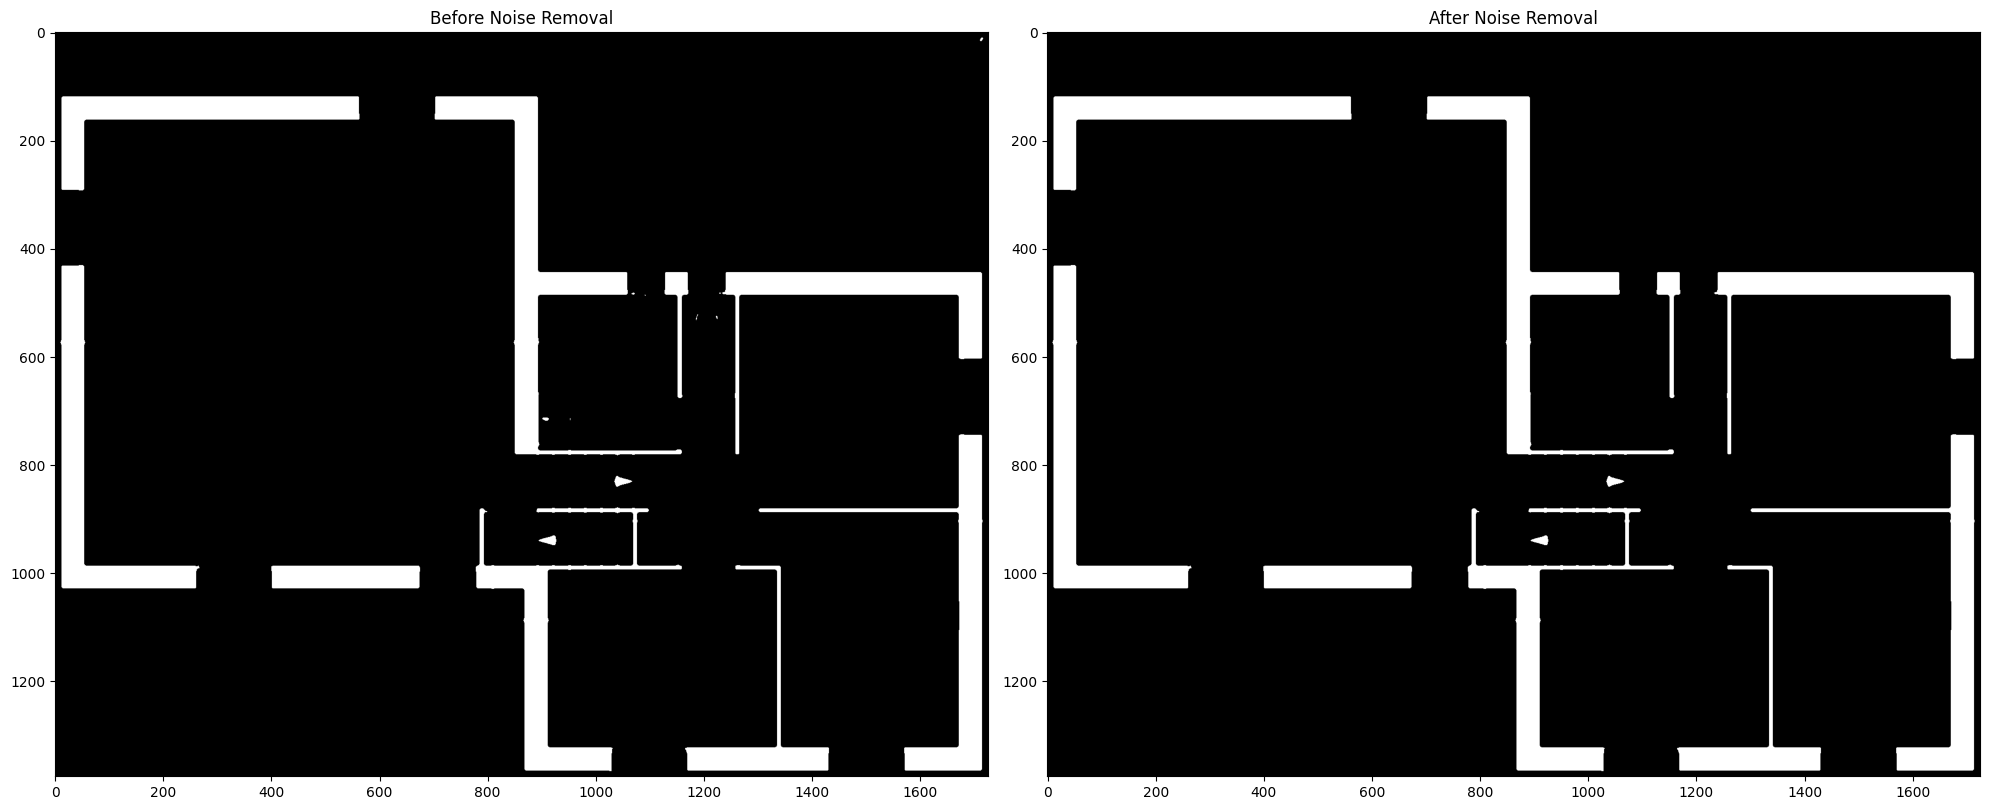

In [4]:
def remove_noise(binary, min_area_ratio=0.0001):
    """
    Remove small connected components.
    min_area_ratio: minimum area as fraction of total image area.
    """
    h, w = binary.shape
    min_area = max(50, int(h * w * min_area_ratio))
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )
    
    cleaned = np.zeros_like(binary)
    kept = 0
    for label_id in range(1, num_labels):  # skip background (0)
        if stats[label_id, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == label_id] = 255
            kept += 1
    
    print(f'Kept {kept} / {num_labels - 1} components (min_area = {min_area})')
    return cleaned

cleaned = remove_noise(cropped, min_area_ratio=0.0001)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(cropped, cmap='gray')
axes[0].set_title('Before Noise Removal')
axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title('After Noise Removal')
plt.tight_layout()
plt.show()

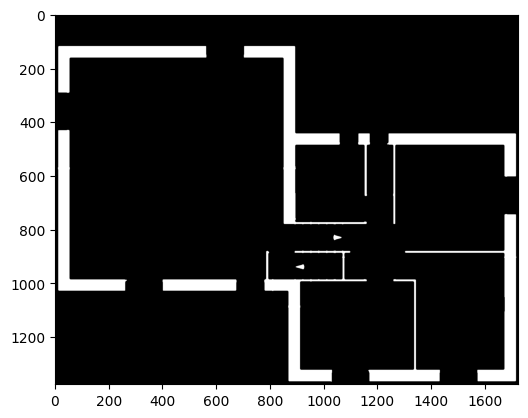

In [5]:
def morphological_cleanup(binary, kernel_size=3):
    """
    Light closing then opening to smooth wall edges.
    Set kernel_size=0 to skip.
    """
    if kernel_size <= 0:
        return binary.copy()
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
    return opened

smoothed = morphological_cleanup(cleaned, kernel_size=3)

plt.imshow(smoothed, cmap='gray')
plt.show()

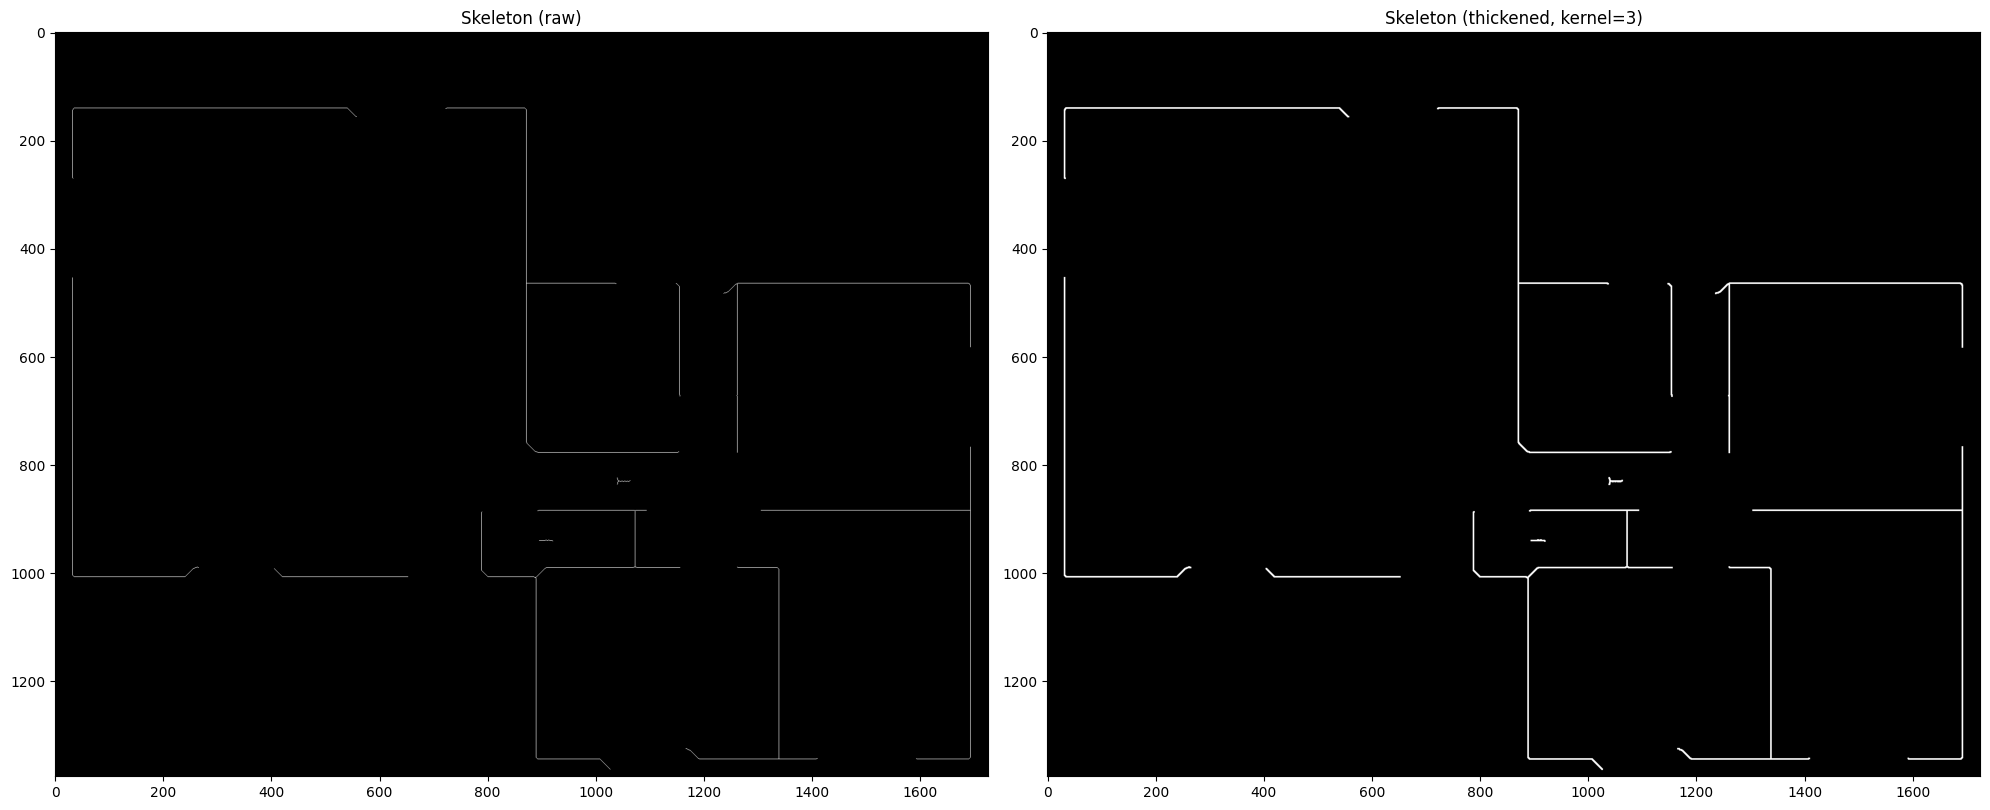

In [6]:
from skimage.morphology import skeletonize
from skimage import img_as_bool

# Skeletonize
skeleton_raw = skeletonize(img_as_bool(smoothed))
skeleton_raw = (skeleton_raw * 255).astype(np.uint8)

# Thicken the skeleton slightly before corner detection
# Increase dilate_size for thicker walls (odd numbers: 3, 5, 7...)
dilate_size = 3
k = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_size, dilate_size))
skeleton = cv2.dilate(skeleton_raw, k)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(skeleton_raw, cmap='gray')
axes[0].set_title('Skeleton (raw)')
axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title(f'Skeleton (thickened, kernel={dilate_size})')
plt.tight_layout()
plt.show()


Polygon corners detected: 122


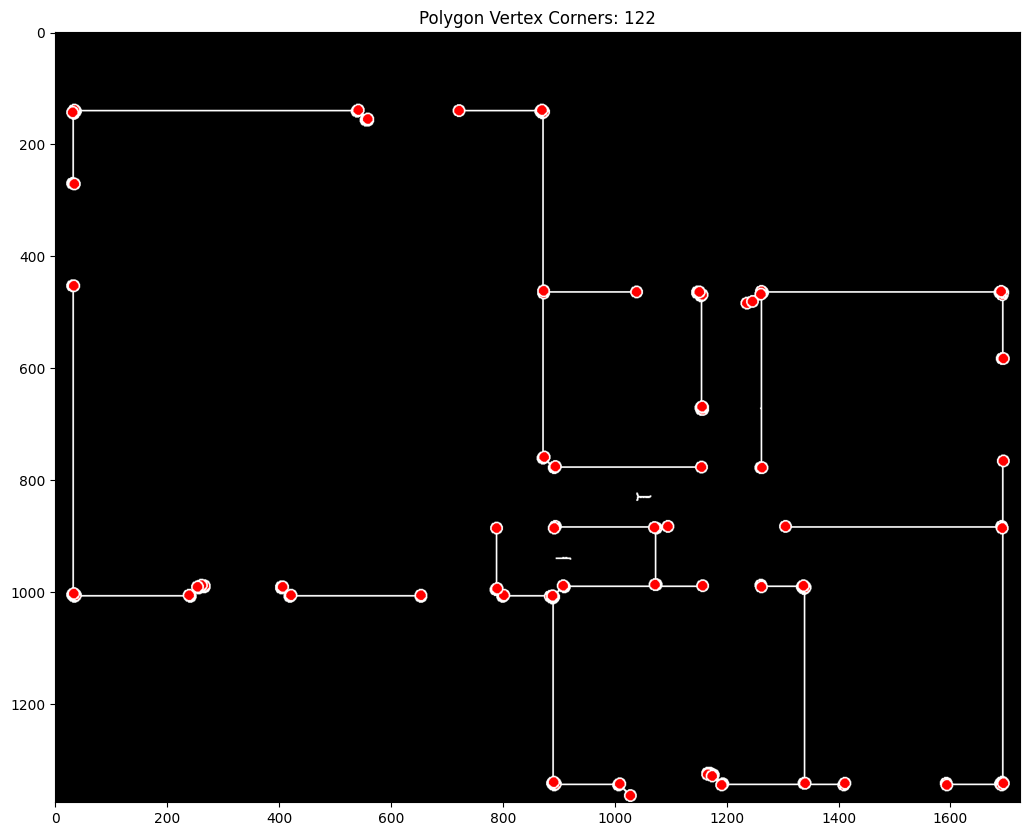

In [7]:
def detect_corners_polygon(binary, min_area=500, epsilon_ratio=0.005):
    """
    Polygon approximation of contours. Vertices = corners.
    
    epsilon_ratio:
      0.001 -> many vertices (subtle bends)
      0.005 -> moderate (default)
      0.02  -> only sharp corners
    """
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    
    corners = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        
        epsilon = epsilon_ratio * cv2.arcLength(cnt, closed=True)
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)
        
        for pt in approx:
            corners.append(tuple(pt[0]))
    
    return corners

poly_corners = detect_corners_polygon(
    skeleton,
    min_area=100,
    epsilon_ratio=0.001
)
print(f'Polygon corners detected: {len(poly_corners)}')

vis = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
for (x, y) in poly_corners:
    cv2.circle(vis, (int(x), int(y)), 10, (0, 0, 255), -1)
    cv2.circle(vis, (int(x), int(y)), 10, (255, 255, 255), 2)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'Polygon Vertex Corners: {len(poly_corners)}')
plt.show()

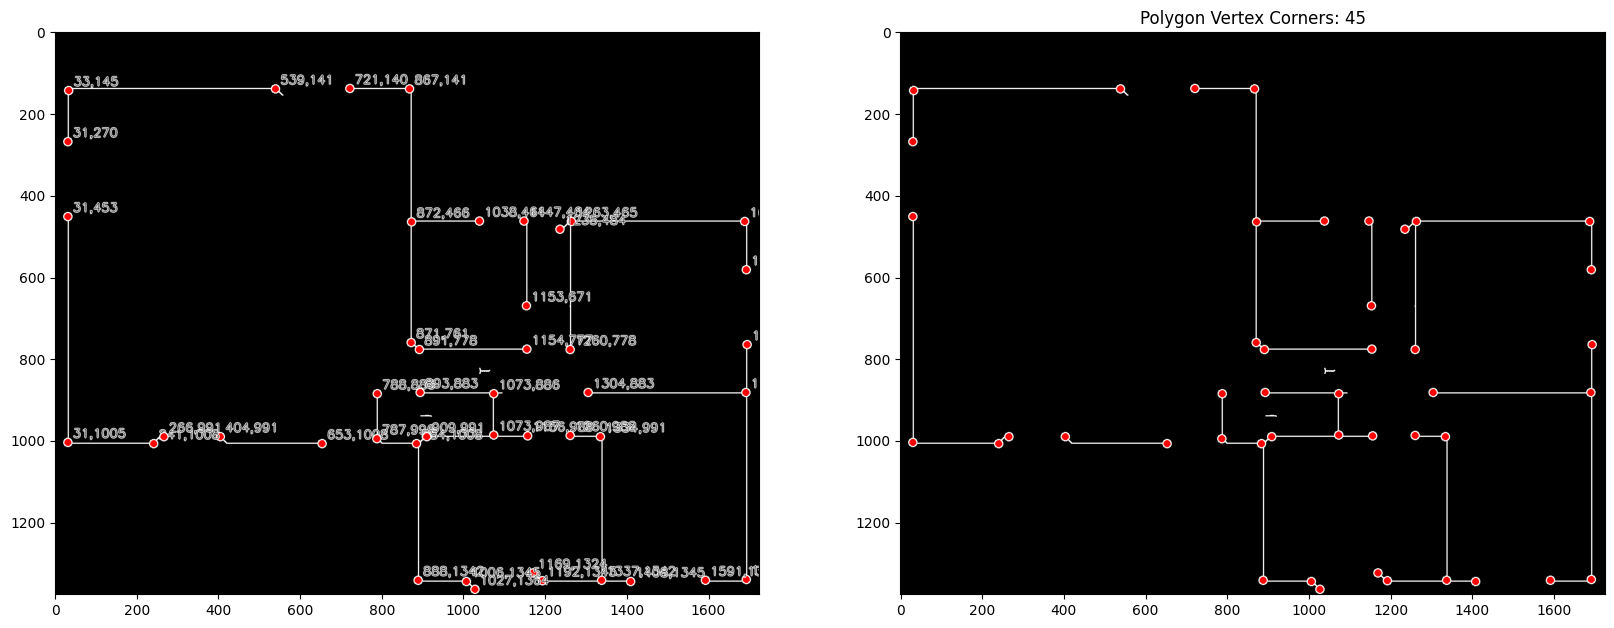

In [8]:
def suppress_neighbors(corners, radius=10):                                                                                                                                                                                                                                                    
      """                                                                                                                                                                                                                                                                                        
      For each corner (in order), remove any other corners within `radius` pixels.                                                                                                                                                                                                               
      First corner encountered in each cluster wins — no scoring, just sweep.                                                                                                                                                                                                                    
      """                                                                                                                                                                                                                                                                                        
      kept = []                                                                                                                                                                                                                                                                                  
      suppressed = set()                                                                                                                                                                                                                                                                         
                  
      for i, (x0, y0) in enumerate(corners):                                                                                                                                                                                                                                                     
          if i in suppressed:
              continue                                                                                                                                                                                                                                                                           
          kept.append((x0, y0))
          for j, (x1, y1) in enumerate(corners):
              if j != i and j not in suppressed:
                  if (x1 - x0) ** 2 + (y1 - y0) ** 2 <= radius ** 2:                                                                                                                                                                                                                             
                      suppressed.add(j)
                                                                                                                                                                                                                                                                                                 
      return kept

kept_corners = suppress_neighbors(poly_corners, 25)
vis = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
vis2 = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
for (x, y) in kept_corners:
    pt = (int(x), int(y))
    cv2.circle(vis, pt, 10, (0, 0, 255), -1)
    cv2.circle(vis, pt, 10, (255, 255, 255), 2)
    cv2.circle(vis2, pt, 10, (0, 0, 255), -1)
    cv2.circle(vis2, pt, 10, (255, 255, 255), 2)
    text = f"{pt[0]},{pt[1]}"
    text_pos = (pt[0] + 12, pt[1] - 12)
    cv2.putText(vis, text, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)
    cv2.putText(vis, text, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 1, cv2.LINE_AA)

fig, ax = plt.subplots(1, 2, figsize=(20, 12))
ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax[1].imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
plt.title(f'Polygon Vertex Corners: {len(kept_corners)}')
plt.show()

Snapped 45 / 45 corners onto skeleton


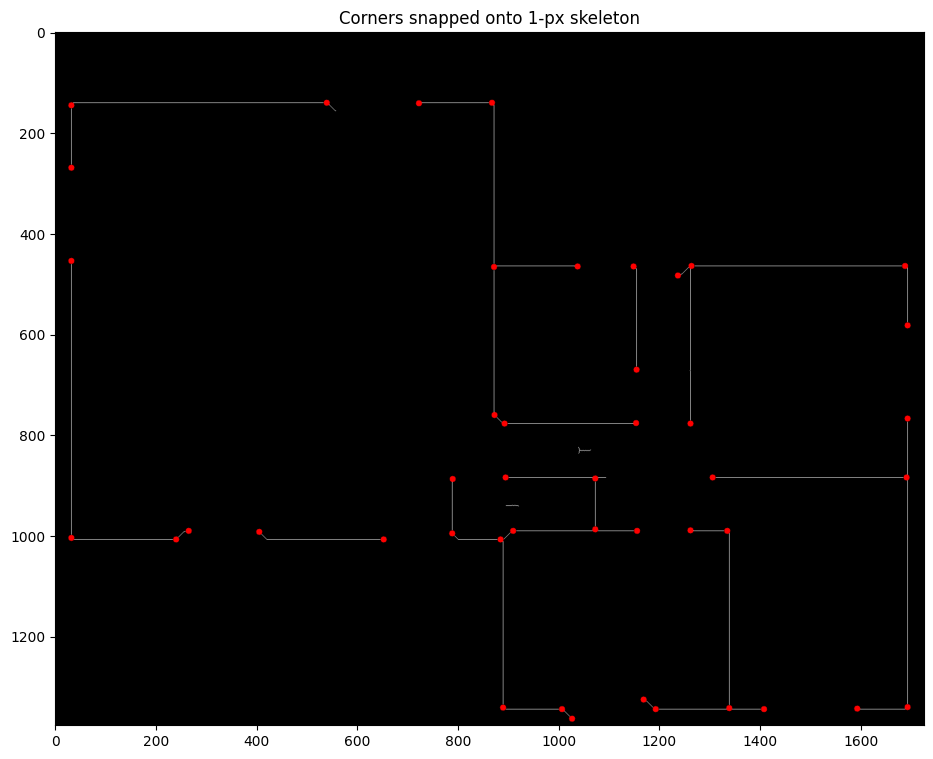

In [9]:
# Step 1: Snap each corner to the nearest skeleton pixel.
# kept_corners came from contours of the *dilated* skeleton, so points sit a few px
# off the 1-px centerline. We need them ON the skeleton so BFS can start from them.

def snap_to_skeleton(corners, skeleton_1px, search_radius=10):
    """
    For each (x, y) corner, find the closest foreground pixel in skeleton_1px
    within a square window of side 2*search_radius+1.
    Returns list of (x, y) snapped onto the skeleton, in same order.
    Corners with no skeleton pixel in range are dropped.
    """
    H, W = skeleton_1px.shape
    snapped = []
    for (x, y) in corners:
        x, y = int(x), int(y)
        x0 = max(0, x - search_radius)
        x1 = min(W, x + search_radius + 1)
        y0 = max(0, y - search_radius)
        y1 = min(H, y + search_radius + 1)

        window = skeleton_1px[y0:y1, x0:x1]
        ys, xs = np.where(window > 0)
        if len(xs) == 0:
            continue  # no skeleton nearby — corner is noise

        # closest foreground pixel by squared distance
        dx = xs + x0 - x
        dy = ys + y0 - y
        idx = np.argmin(dx * dx + dy * dy)
        snapped.append((int(xs[idx] + x0), int(ys[idx] + y0)))
    return snapped

snapped_corners = snap_to_skeleton(kept_corners, skeleton_raw, search_radius=10)
print(f'Snapped {len(snapped_corners)} / {len(kept_corners)} corners onto skeleton')

# Sanity check overlay
vis = cv2.cvtColor(skeleton_raw, cv2.COLOR_GRAY2BGR)
for (x, y) in snapped_corners:
    cv2.circle(vis, (x, y), 6, (0, 0, 255), -1)
plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Corners snapped onto 1-px skeleton')
plt.show()


In [10]:
# Step 2: Multi-source BFS along the skeleton.
# Each corner becomes a "seed". Every skeleton pixel gets claimed by the
# nearest corner (in graph distance, not Euclidean). When two territories
# touch, we record an edge between those two corners — meaning there is a
# skeleton path between them with no other corner in between.

from collections import deque

def bfs_edges(snapped_corners, skeleton_1px):
    """
    Returns:
      edges: set of frozenset({i, j}) — corner index pairs connected via skeleton
      edge_lengths: dict frozenset({i, j}) -> geodesic length in pixels
    """
    H, W = skeleton_1px.shape
    labels = -np.ones((H, W), dtype=np.int32)   # which corner claims this pixel
    dist   = -np.ones((H, W), dtype=np.int32)   # BFS depth from that corner

    q = deque()
    for cid, (x, y) in enumerate(snapped_corners):
        # If two corners snapped to the same pixel, the first one wins.
        if labels[y, x] == -1:
            labels[y, x] = cid
            dist[y, x] = 0
            q.append((y, x))

    edges = {}  # frozenset -> length

    # 8-connectivity
    nbrs = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while q:
        y, x = q.popleft()
        my_label = labels[y, x]
        my_dist  = dist[y, x]

        for dy, dx in nbrs:
            ny, nx = y + dy, x + dx
            if ny < 0 or ny >= H or nx < 0 or nx >= W:
                continue
            if skeleton_1px[ny, nx] == 0:
                continue

            if labels[ny, nx] == -1:
                labels[ny, nx] = my_label
                dist[ny, nx] = my_dist + 1
                q.append((ny, nx))
            elif labels[ny, nx] != my_label:
                # Frontier collision — record an edge.
                key = frozenset({my_label, int(labels[ny, nx])})
                length = my_dist + dist[ny, nx] + 1
                # Keep shortest geodesic if we hit it from multiple frontiers.
                if key not in edges or length < edges[key]:
                    edges[key] = length

    return edges, labels

edge_dict, label_map = bfs_edges(snapped_corners, skeleton_raw)
print(f'Found {len(edge_dict)} edges among {len(snapped_corners)} corners')


Found 36 edges among 45 corners


In [11]:
# Step 3: Build the networkx graph.
# Node attribute: pixel coordinate (x, y).
# Edge attribute: geodesic length along the skeleton (pixels).

import networkx as nx

G = nx.Graph()
for cid, (x, y) in enumerate(snapped_corners):
    G.add_node(cid, x=x, y=y)

for key, length in edge_dict.items():
    a, b = tuple(key)
    G.add_edge(a, b, length=int(length))

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Connected components: {nx.number_connected_components(G)}')


Graph: 45 nodes, 36 edges
Connected components: 9


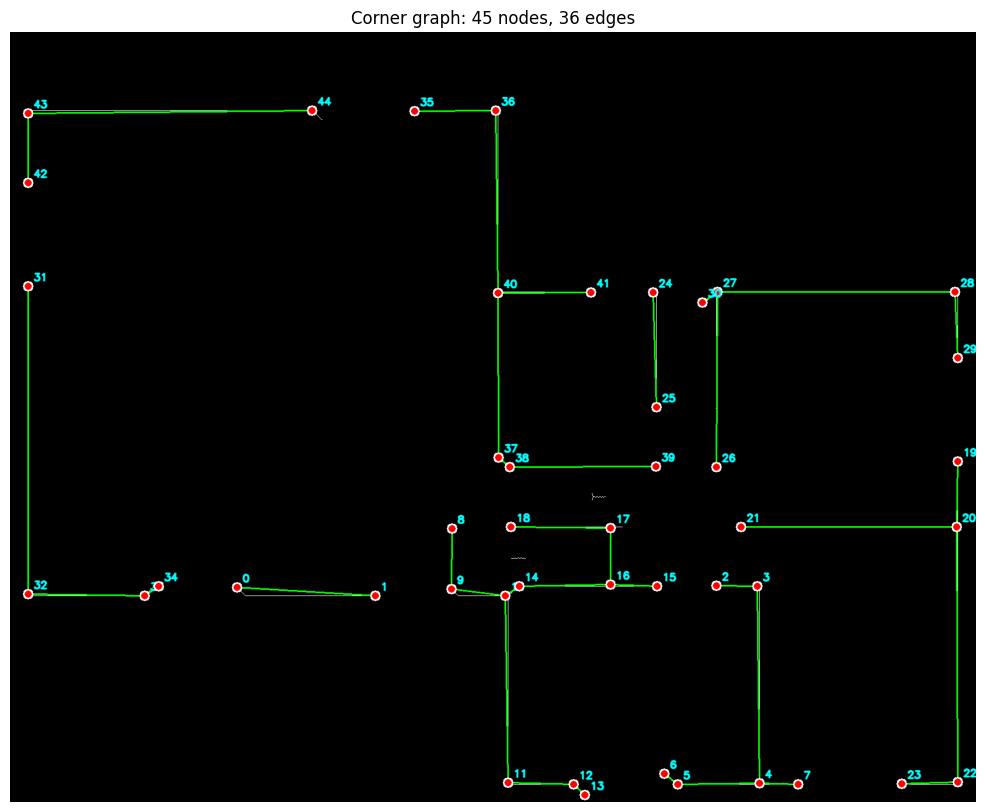

In [12]:
# Step 4: Visualize the graph overlaid on the skeleton.

vis = cv2.cvtColor(skeleton_raw, cv2.COLOR_GRAY2BGR)

# edges
for a, b in G.edges():
    pa = (G.nodes[a]['x'], G.nodes[a]['y'])
    pb = (G.nodes[b]['x'], G.nodes[b]['y'])
    cv2.line(vis, pa, pb, (0, 255, 0), 2)

# nodes
for n, attr in G.nodes(data=True):
    p = (attr['x'], attr['y'])
    cv2.circle(vis, p, 8, (0, 0, 255), -1)
    cv2.circle(vis, p, 8, (255, 255, 255), 2)
    cv2.putText(vis, str(n), (p[0] + 10, p[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'Corner graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
plt.axis('off')
plt.show()


DAG: 45 nodes, 36 edges
Trees (weakly connected components): 9
Edges dropped to break cycles: 0


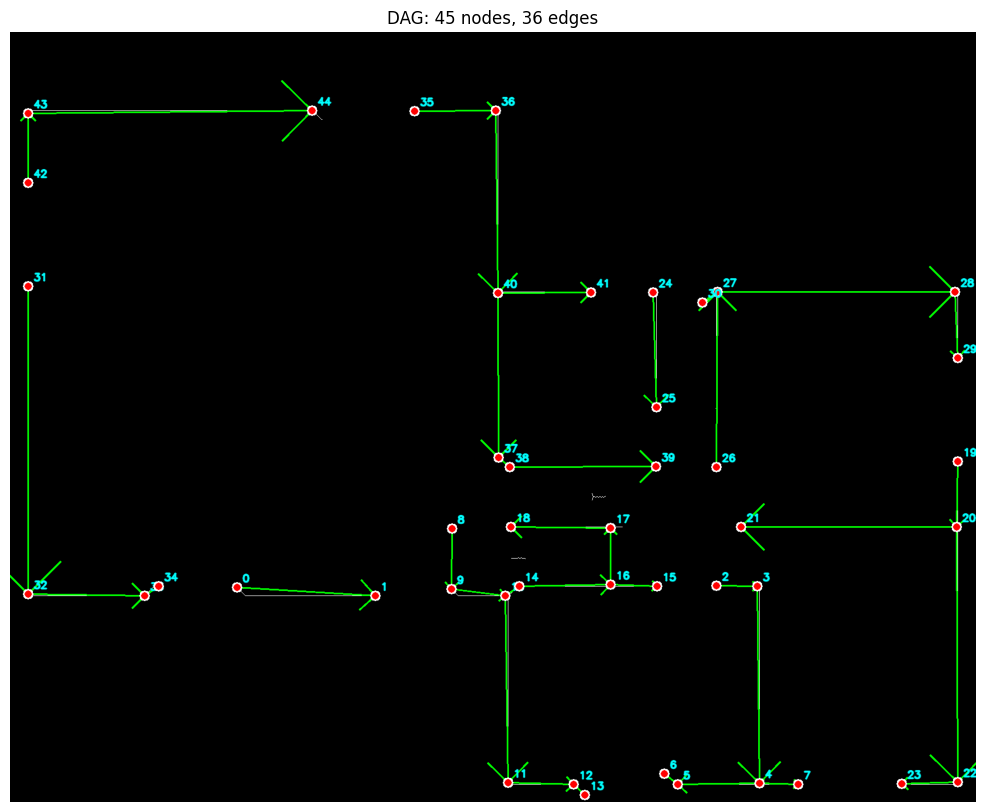

In [13]:
# Step 5: Convert the undirected graph to a DAG.
# Strategy: per connected component, pick a root and run DFS, directing each
# edge from parent -> child. Back-edges that would close a cycle are dropped.
# Result is a forest (one tree per component), which is trivially a DAG.

DAG = nx.DiGraph()
for n, attr in G.nodes(data=True):
    DAG.add_node(n, **attr)

for component in nx.connected_components(G):
    sub = G.subgraph(component)
    # Deterministic root: smallest node id in this component.
    root = min(component)
    for parent, child in nx.dfs_edges(sub, source=root):
        DAG.add_edge(parent, child, length=sub[parent][child]['length'])

assert nx.is_directed_acyclic_graph(DAG), 'Result is not a DAG'
print(f'DAG: {DAG.number_of_nodes()} nodes, {DAG.number_of_edges()} edges')
print(f'Trees (weakly connected components): {nx.number_weakly_connected_components(DAG)}')
print(f'Edges dropped to break cycles: {G.number_of_edges() - DAG.number_of_edges()}')

# Visualize: arrows go parent -> child.
vis = cv2.cvtColor(skeleton_raw, cv2.COLOR_GRAY2BGR)
for parent, child in DAG.edges():
    pa = (DAG.nodes[parent]['x'], DAG.nodes[parent]['y'])
    pb = (DAG.nodes[child]['x'], DAG.nodes[child]['y'])
    cv2.arrowedLine(vis, pa, pb, (0, 255, 0), 2, tipLength=0.15)

for n, attr in DAG.nodes(data=True):
    p = (attr['x'], attr['y'])
    cv2.circle(vis, p, 8, (0, 0, 255), -1)
    cv2.circle(vis, p, 8, (255, 255, 255), 2)
    cv2.putText(vis, str(n), (p[0] + 10, p[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'DAG: {DAG.number_of_nodes()} nodes, {DAG.number_of_edges()} edges')
plt.axis('off')
plt.show()

In [14]:
source = random.choice(list(DAG.nodes))
nodes = list(nx.dfs_edges(DAG, source=source))
for i in range(len(nodes)):
    current_node, next_node = nodes[i]
    x1, y1 = DAG.nodes[current_node]["x"], DAG.nodes[current_node]["y"]
    x2, y2 = DAG.nodes[next_node]["x"], DAG.nodes[next_node]["y"]
    print(f"Current node ({current_node}): ({x1}, {y1}) --> Next node ({next_node}): ({x2}, {y2})")

Current node (42): (32, 269) --> Next node (43): (32, 145)
Current node (43): (32, 145) --> Next node (44): (539, 140)


In [15]:
import pandas as pd

rows = []
for parent, child in DAG.edges():
    x1, y1 = DAG.nodes[parent]['x'], DAG.nodes[parent]['y']
    x2, y2 = DAG.nodes[child]['x'],  DAG.nodes[child]['y']
    rows.append((x1, y1, x2, y2))

df = pd.DataFrame(rows, columns=['x1', 'y1', 'x2', 'y2'])
df.to_csv("coordinate_test.csv", index=False)
print(df.shape)
df.head()

(36, 4)


,x1,y1,x2,y2
0,405,992,652,1007
1,1261,989,1334,990
2,1334,990,1338,1342
3,1338,1342,1407,1344
4,1338,1342,1192,1344


In [16]:
end_time = time.perf_counter()

elapsed = end_time - start_time
print(f"Elapsed time: {elapsed:.4f} s")

Elapsed time: 1.8887 s


In [17]:
# import os
# from pathlib import Path

# output_dir = "../data/PNG/skeleton_corners"
# os.makedirs(output_dir, exist_ok=True)
# for img_path in images_path:
#     fname = os.path.basename(img_path)
#     new_path = Path(output_dir, fname)
#     img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#     _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
#     cropped = crop_to_content(binary, margin=-10)
#     cleaned = remove_noise(cropped, min_area_ratio=0.0001)
#     smoothed = morphological_cleanup(cleaned, kernel_size=3)

#     skeleton_raw = skeletonize(img_as_bool(smoothed))
#     skeleton_raw = (skeleton_raw * 255).astype(np.uint8)

#     # Thicken the skeleton slightly before corner detection
#     # Increase dilate_size for thicker walls (odd numbers: 3, 5, 7...)
#     dilate_size = 3
#     k = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_size, dilate_size))
#     skeleton = cv2.dilate(skeleton_raw, k)

#     poly_corners = detect_corners_polygon(
#         skeleton,
#         min_area=100,
#         epsilon_ratio=0.005
#     )

#     kept_corners = suppress_neighbors(poly_corners, 25)
#     vis = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
#     for (x, y) in kept_corners:
#         cv2.circle(vis, (int(x), int(y)), 10, (0, 0, 255), -1)
#         cv2.circle(vis, (int(x), int(y)), 10, (255, 255, 255), 2)

#     plt.imsave(new_path, cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))